In [4]:
#Question 1
import numpy as np

def multi_var_linear(x, y, iterations, learning_rate):
    # Initialize weights and bias
    b1 = np.random.randn(x.shape[1], 1)  # Shape (n_features, 1)
    b0 = 0.0  # Scalar bias

    mse_hist = []

    for k in range(iterations):
        # Predict
        y_pred = b0 + np.dot(x, b1)  # Shape (n_samples, 1)

        # Update bias (b0)
        b0 -= learning_rate * np.sum(y_pred - y) / len(y)

        # Update weights (b1)
        y_diff = y_pred - y  # Shape (n_samples, 1)
        b1 -= learning_rate * np.dot(x.T, y_diff) / len(y)  # x.T is (n_features, n_samples)

        # Calculate Mean Squared Error
        mse = np.mean(np.square(y_pred - y))  # Mean Squared Error
        mse_hist.append(mse)

    # Combine bias and weights into a single vector
    vector_weights = np.vstack((b0, b1))  # Stacking bias and weights
    return vector_weights, mse_hist

# Example of how to call the function
x = np.random.rand(100, 3)  # 100 samples, 3 features
y = np.random.rand(100, 1)   # 100 target values

weights, mse_history = multi_var_linear(x, y, iterations=1000, learning_rate=0.01)

print("Weights:\n", weights)
print("MSE History:\n", mse_history)


Weights:
 [[ 1.09463602]
 [-0.07354506]
 [-0.41386248]
 [-0.68050986]]
MSE History:
 [6.435718679708228, 6.2204098686607425, 6.012568586068043, 5.811935654608592, 5.6182608925089905, 5.431302801325453, 5.2508282645618, 5.076612256747852, 4.9084375626151795, 4.746094506019707, 4.589380688272928, 4.438100735555134, 4.292066055095464, 4.151094599814484, 4.0150106411355715, 3.8836445496815997, 3.756832583583223, 3.6344166841345746, 3.5162442785413863, 3.402168089515338, 3.2920459514770255, 3.1857406331381917, 3.083119666241783, 2.9840551802461137, 2.8884237427468444, 2.7961062054375994, 2.7069875554170046, 2.6209567716565902, 2.5379066864504027, 2.45773385167345, 2.38033840968207, 2.305623968695088, 2.233497482500277, 2.163869134335967, 2.096652224802912, 2.031763063666523, 1.969120865414442, 1.9086476484391133, 1.8502681377195436, 1.7939096708807876, 1.7395021075139399, 1.6869777416434504, 1.6362712172325424, 1.5873194466212743, 1.5400615317954622, 1.494438688388212, 1.450394172319213, 1.

In [12]:
#Question 1
import numpy as np

def multi_var_linear(x, y, iterations, learning_rate):
    # Add a column of ones to x to account for the intercept (b0)
    x = np.hstack((np.ones((x.shape[0], 1)), x))  # Shape (n_samples, n_features + 1)

    # Initialize weights (including the intercept)
    weights = np.random.randn(x.shape[1], 1)  # Shape (n_features + 1, 1)

    mse_hist = []

    for _ in range(iterations):
        # Predict
        y_pred = np.dot(x, weights)  # Shape (n_samples, 1)

        # Calculate the error
        error = y_pred - y.reshape(-1, 1)  # Reshape y to (n_samples, 1)

        # Update weights
        weights -= learning_rate * (np.dot(x.T, error) / len(y))  # Gradient descent step

        # Calculate Mean Squared Error
        mse = np.sum(np.square(error)) / len(y)
        mse_hist.append(mse)

    return weights.flatten(), mse_hist  # Return weights as 1D array and MSE history

# Example usage
x = np.random.rand(100, 3)  # 100 samples, 3 features
y = np.random.rand(100)      # 100 target values (1D array)

weights, mse_history = multi_var_linear(x, y, iterations=1000, learning_rate=0.01)

print("Weights (including intercept):\n", weights)
print("MSE History:\n", mse_history)


Weights (including intercept):
 [ 0.3850362  -0.73089431  0.61438577  0.39006794]
MSE History:
 [0.7092295818712471, 0.6944016414754092, 0.680089953607836, 0.6662761990339066, 0.6529427090878887, 0.6400724425686035, 0.6276489634556176, 0.6156564194168249, 0.6040795210793126, 0.5929035220364035, 0.5821141995647305, 0.5716978360261273, 0.5616412009300132, 0.5519315336328159, 0.542556526651811, 0.5335043095715531, 0.5247634335218573, 0.5163228562070287, 0.5081719274667685, 0.5003003753498697, 0.49269829268249254, 0.48535612411345724, 0.4782646536196102, 0.47141499245492574, 0.4647985675275864, 0.4584071101898379, 0.45223264542596503, 0.4462674814242454, 0.4405041995192463, 0.43493564449131106, 0.4295549152105519, 0.42435535561311144, 0.4193305459978951, 0.41447429463239144, 0.4097806296566055, 0.4052437912745149, 0.40085822422284084, 0.3966185705072827, 0.3925196623967201, 0.3885565156662177, 0.3847243230800004, 0.38101844810587393, 0.3774344188528717, 0.37396792222420167, 0.3706147982778

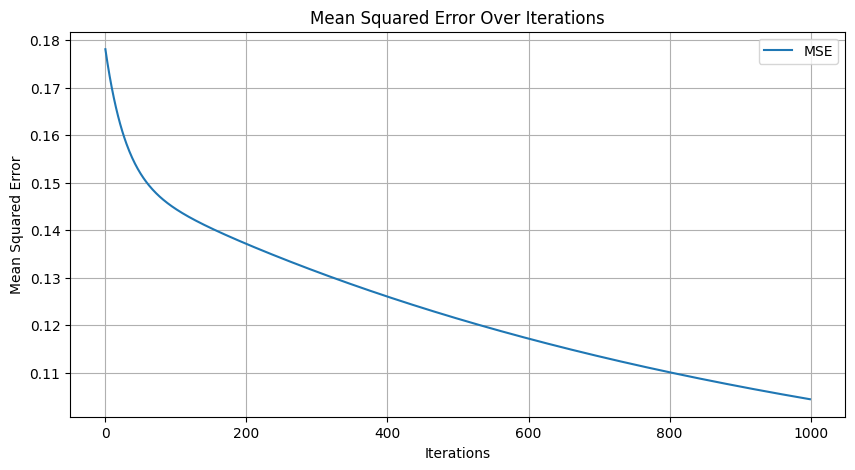

Weights (including intercept):
 [ 1.18523414 -0.45698615 -0.36618172 -0.56407676]


In [13]:
#Question 1
import numpy as np
import matplotlib.pyplot as plt

def multi_var_linear(x, y, iterations, learning_rate):
    # Add a column of ones to x to account for the intercept (b0)
    x = np.hstack((np.ones((x.shape[0], 1)), x))  # Shape (n_samples, n_features + 1)

    # Initialize weights (including the intercept)
    weights = np.random.randn(x.shape[1], 1)  # Shape (n_features + 1, 1)

    mse_hist = []

    for _ in range(iterations):
        # Predict
        y_pred = np.dot(x, weights)  # Shape (n_samples, 1)

        # Calculate the error
        error = y_pred - y.reshape(-1, 1)  # Reshape y to (n_samples, 1)

        # Update weights
        weights -= learning_rate * (np.dot(x.T, error) / len(y))  # Gradient descent step

        # Calculate Mean Squared Error
        mse = np.sum(np.square(error)) / len(y)
        mse_hist.append(mse)

    return weights.flatten(), mse_hist  # Return weights as 1D array and MSE history

# Example usage
x = np.random.rand(100, 3)  # 100 samples, 3 features
y = np.random.rand(100)      # 100 target values (1D array)

weights, mse_history = multi_var_linear(x, y, iterations=1000, learning_rate=0.01)

# Plotting the Mean Squared Error history
plt.figure(figsize=(10, 5))
plt.plot(mse_history, label='MSE')
plt.title('Mean Squared Error Over Iterations')
plt.xlabel('Iterations')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True)
plt.show()

print("Weights (including intercept):\n", weights)


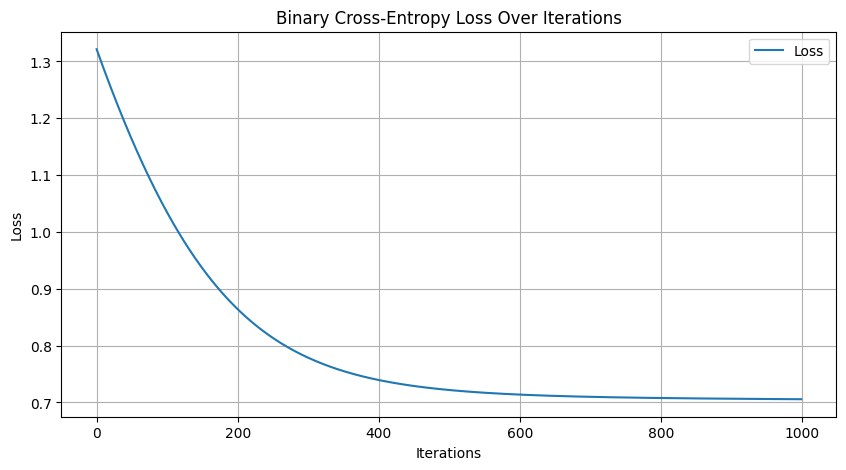

Weights (including intercept):
 [-0.10352725 -0.11119098 -0.78024751  0.91964215]


In [6]:

#Question 2
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def multi_var_logistic_regression(x, y, iterations, learning_rate):
    # Add a column of ones to x to account for the intercept (b0)
    x = np.hstack((np.ones((x.shape[0], 1)), x))  # Shape (n_samples, n_features + 1)

    # Initialize weights (including the intercept)
    weights = np.random.randn(x.shape[1], 1)  # Shape (n_features + 1, 1)

    # Loss history for plotting
    loss_history = []

    for _ in range(iterations):
        # Predict probabilities
        z = np.dot(x, weights)  # Shape (n_samples, 1)
        y_pred = sigmoid(z)  # Shape (n_samples, 1)

        # Calculate the error
        error = y_pred - y.reshape(-1, 1)  # Reshape y to (n_samples, 1)

        # Update weights
        weights -= learning_rate * (np.dot(x.T, error) / len(y))  # Gradient descent step

        # Calculate Binary Cross-Entropy Loss
        loss = -np.mean(y * np.log(y_pred + 1e-15) + (1 - y) * np.log(1 - y_pred + 1e-15))
        loss_history.append(loss)

    return weights.flatten(), loss_history  # Return weights as 1D array and loss history

# Example usage
x = np.random.rand(100, 3)  # 100 samples, 3 features
y = np.random.randint(0, 2, 100)  # 100 binary target values (0s and 1s)

weights, loss_history = multi_var_logistic_regression(x, y, iterations=1000, learning_rate=0.01)

# Plotting the loss history
plt.figure(figsize=(10, 5))
plt.plot(loss_history, label='Loss')
plt.title('Binary Cross-Entropy Loss Over Iterations')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

print("Weights (including intercept):\n", weights)


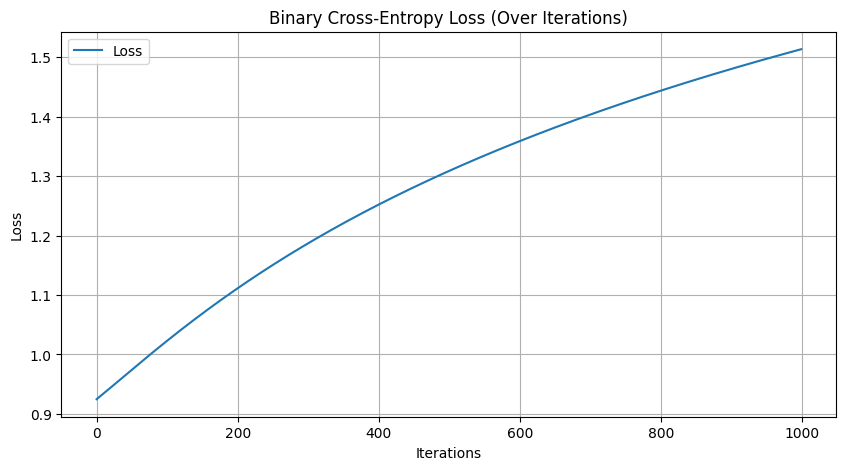

Weights (including intercept):
 [-0.22173197  1.08640024  1.4738456 ]


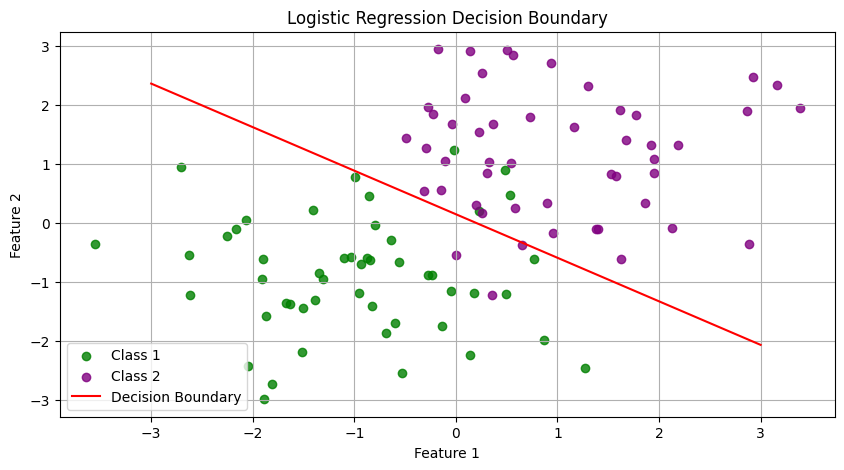

In [14]:
#Question 2

import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def multi_var_logistic_regression(x, y, iterations, learning_rate):
    # Add a column of ones to x to account for the intercept (b0)
    x = np.hstack((np.ones((x.shape[0], 1)), x))  # Shape (n_samples, n_features + 1)

    # Initialize weights (including the intercept)
    weights = np.random.randn(x.shape[1], 1)  # Shape (n_features + 1, 1)

    # Loss history for plotting
    loss_history = []

    for _ in range(iterations):
        # Predict probabilities
        z = np.dot(x, weights)  # Shape (n_samples, 1)
        y_pred = sigmoid(z)  # Shape (n_samples, 1)

        # Calculate the error
        error = y_pred - y.reshape(-1, 1)  # Reshape y to (n_samples, 1)

        # Update weights
        weights -= learning_rate * (np.dot(x.T, error) / len(y))  # Gradient descent step

        # Calculate Binary Cross-Entropy Loss
        loss = -np.mean(y * np.log(y_pred + 1e-15) + (1 - y) * np.log(1 - y_pred + 1e-15))
        loss_history.append(loss)

    return weights.flatten(), loss_history  # Return weights as 1D array and loss history

# Generate synthetic data
np.random.seed(0)  # For reproducibility
num_samples = 100

# Generate two classes of data
x_class0 = np.random.randn(num_samples // 2, 2) - 1  # Class 0
x_class1 = np.random.randn(num_samples // 2, 2) + 1  # Class 1
x = np.vstack((x_class0, x_class1))  # Shape (100, 2)

y = np.array([0] * (num_samples // 2) + [1] * (num_samples // 2))  # Labels (0s and 1s)

# Train the logistic regression model
weights, loss_history = multi_var_logistic_regression(x, y, iterations=1000, learning_rate=0.01)

# Plotting the loss history
plt.figure(figsize=(10, 5))
plt.plot(loss_history, label='Loss')
plt.title('Binary Cross-Entropy Loss (Over Iterations)')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

print("Weights (including intercept):\n", weights)

# Plotting the data and decision boundary
plt.figure(figsize=(10, 5))
plt.scatter(x[y == 0][:, 0], x[y == 0][:, 1], label='Class 1', color='green', alpha=0.8)
plt.scatter(x[y == 1][:, 0], x[y == 1][:, 1], label='Class 2', color='purple', alpha=0.8)

# Decision boundary
x_boundary = np.linspace(-3, 3, 100)
y_boundary = -(weights[0] + weights[1] * x_boundary) / weights[2]

plt.plot(x_boundary, y_boundary, label='Decision Boundary', color='red')
plt.title('Logistic Regression Decision Boundary')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()
